In [1]:
import sys, os; sys.path.append(os.path.dirname(os.getcwd())) 

from mpl_toolkits import mplot3d

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
from tqdm import tqdm
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.utils.validation import check_is_fitted
from sklearn.preprocessing import MinMaxScaler

from pyfrechet.metric_spaces import MetricData, Sphere

import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

INFO: Using numpy backend


# Hypersphere 

In [127]:
# read hyp_points.csv
import sys, os
import pandas as pd
hyp_points = pd.read_csv('/Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/simulations_H2/dibujo/H2_dibujo_repst200_kappa200.csv')
hyp_points.drop(columns = ['Unnamed: 0'], inplace = True)
#name columns 1, 2 and 4 as V1, V2 and V3
hyp_points.columns = ['t', 'V1', 'V2', 'V3']

In [128]:
hyp_points

,t,V1,V2,V3
0,-0.8,1.353488,-0.610412,-0.677736
1,-0.8,1.422301,-0.615892,-0.802258
2,-0.8,1.003552,-0.081750,-0.020828
3,-0.8,1.168741,-0.455636,-0.397933
4,-0.8,1.292566,-0.535108,-0.619988
...,...,...,...,...
995,0.8,1.360396,0.636478,0.667512
996,0.8,1.315072,0.565589,0.639939
997,0.8,1.242654,0.553980,0.487129
998,0.8,1.236998,0.539682,0.488780


In [117]:
# read hyp_points.csv
import sys, os
import pandas as pd
hyp_points = pd.read_csv(os.path.join(os.getcwd(),'simulations_H2', 'hyp_points.csv') )
hyp_points.drop(columns = ['Unnamed: 0'], inplace = True)
#name columns 1, 2 and 4 as V1, V2 and V3
hyp_points.columns = ['t', 'V1', 'V2', 'V3']

In [2]:
# read hyp_points.csv
import sys, os
import pandas as pd
hyp_points = pd.read_csv('/Users/Diego/Desktop/Codigo/repo_edu_pyfrechet/pyfrechet/simulations_H2/TypeIIdata/samp_1_N_50_kappa50.csv')
hyp_points.drop(columns = ['Unnamed: 0'], inplace = True)
#name columns 1, 2 and 4 as V1, V2 and V3
hyp_points.columns = ['t', 'V1', 'V2', 'V3']

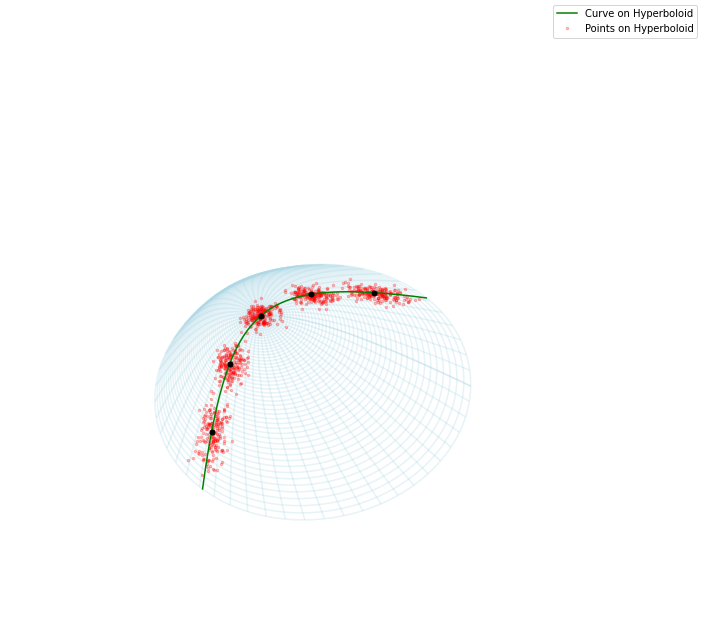

In [267]:
#For hyperboloid
u = np.linspace(0, 1, 1000)
v = np.linspace(0, 2*np.pi, 1000)

u, v = np.meshgrid(u, v)

x_grid = np.cosh(np.abs(u))
y_grid = np.sinh(np.abs(u)) * np.sign(u) * np.cos(v)
z_grid = np.sinh(np.abs(u)) * np.sign(u) * np.sin(v)

# Define the parameter theta
theta = np.linspace(-1, 1, 10000)

# Generate 10 random unit vectors in R2
mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2

fig=plt.figure()
fig.set_size_inches(12, 10)
ax=plt.axes(projection='3d', computed_zorder=False)

x_curve = np.cosh(np.abs(theta))
y_curve = np.sinh(np.abs(theta)) * np.sign(theta) * mu[0]
z_curve = np.sinh(np.abs(theta)) * np.sign(theta) * mu[1]
ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)
# ax.plot_surface(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)

ax.plot(x_curve, y_curve, z_curve, color='green', label='Curve on Hyperboloid', zorder = 1)

# Centers
ax.plot(hyp_points['V1'], hyp_points['V2'], hyp_points['V3'], color='red', marker = '.', lw = 0, markersize = 5, label='Points on Hyperboloid', alpha = 0.25, zorder = 0)

ax.plot(np.cosh(0.8), np.sinh(0.8) * mu[0], np.sinh(0.8) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.45), np.sinh(0.45) * mu[0], np.sinh(0.45) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0), np.sinh(0) * mu[0], np.sinh(0) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.45), -np.sinh(0.45) * mu[0], -np.sinh(0.45) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.8), -np.sinh(0.8) * mu[0], -np.sinh(0.8) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
#ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)

ax.view_init(elev=15, azim=-10, roll = 0)
ax.grid(False)
ax.set_axis_off()
fig.legend()
plt.show()

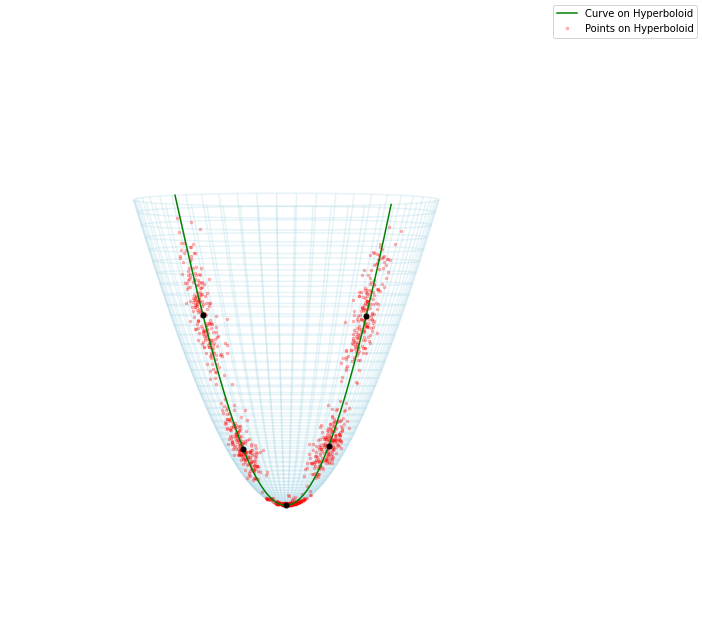

In [264]:
#For hyperboloid
u = np.linspace(0, 1, 1000)
v = np.linspace(0, 2*np.pi, 1000)

u, v = np.meshgrid(u, v)

x_grid = np.cosh(np.abs(u))
y_grid = np.sinh(np.abs(u)) * np.sign(u) * np.cos(v)
z_grid = np.sinh(np.abs(u)) * np.sign(u) * np.sin(v)

# Define the parameter theta
theta = np.linspace(-1, 1, 10000)

# Generate 10 random unit vectors in R2
mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2

fig=plt.figure()
fig.set_size_inches(12, 10)
ax=plt.axes(projection='3d', computed_zorder=False)

x_curve = np.cosh(np.abs(theta))
y_curve = np.sinh(np.abs(theta)) * np.sign(theta) * mu[0]
z_curve = np.sinh(np.abs(theta)) * np.sign(theta) * mu[1]
ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)
# ax.plot_surface(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)

ax.plot(x_curve, y_curve, z_curve, color='green', label='Curve on Hyperboloid', zorder = 1)

# Centers
ax.plot(hyp_points['V1'], hyp_points['V2'], hyp_points['V3'], color='red', marker = '.', lw = 0, markersize = 5, label='Points on Hyperboloid', alpha = 0.25, zorder = 0)

ax.plot(np.cosh(0.8), np.sinh(0.8) * mu[0], np.sinh(0.8) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.45), np.sinh(0.45) * mu[0], np.sinh(0.45) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0), np.sinh(0) * mu[0], np.sinh(0) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.45), -np.sinh(0.45) * mu[0], -np.sinh(0.45) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
ax.plot(np.cosh(0.8), -np.sinh(0.8) * mu[0], -np.sinh(0.8) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)
#ax.plot_wireframe(x_grid, y_grid, z_grid, color='lightblue', alpha=0.3, zorder = 0)

ax.view_init(elev = 90, azim = 0, roll = 180)
ax.grid(False)
ax.set_axis_off()
fig.legend()
plt.show()

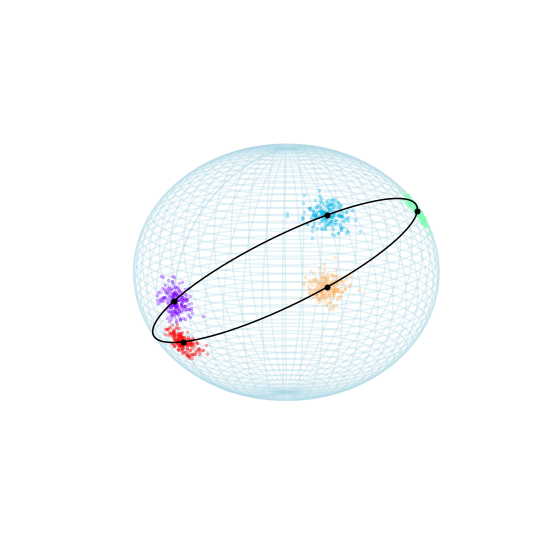

In [272]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import vonmises_fisher

# Function defining the regression mean m_0(theta) on S^2
def m_0(theta, mu):
    """
    Compute the regression mean on S^2.
    
    Parameters:
    theta : array-like
        Angles in [0, 2pi) that parameterize the great circle.
    mu : array-like, shape (2,)
        A unit vector defining the orientation of the great circle.
    
    Returns:
    array, shape (n, 3)
        The mean directions on S^2.
    """
    theta = np.asarray(theta)
    mu = np.asarray(mu)
    assert mu.shape == (2,) and np.isclose(np.linalg.norm(mu), 1), "mu must be a unit vector in R^2"
    
    x1 = np.cos(theta)
    x2 = np.sin(theta) * mu[0]
    x3 = np.sin(theta) * mu[1]
    
    return np.column_stack((x1, x2, x3))

# Function to generate vMF samples
def simulate_data(kappa, mu, theta_samples):
    """
    Generate samples from the von Mises-Fisher distribution on S^2.
    
    Parameters:
    sample_size : int
        Number of samples to generate.
    kappa : float
        Concentration parameter of the vMF distribution.
    mu : array-like, shape (2,)
        The unit vector defining the great circle.
    
    Returns:
    dict
        A dictionary containing input angles and generated samples.
    """
    mean_directions = m_0(theta_samples, mu)  # Compute means on S^2
    
    samples = [vonmises_fisher(mean, kappa).rvs(200) for mean in mean_directions]
    
    return theta_samples, np.array(samples)

mu = np.array([1/np.sqrt(2), 1/np.sqrt(2)])  # Fixed unit vector in R^2


# Create directory for saving samples
save_folder = os.path.join(os.getcwd(), 'simulations_sphere', 'data')
os.makedirs(save_folder, exist_ok=True)

np.random.seed(1000)
sample_size = 1000
kappa = 200
theta_centers = np.array([0, 2*np.pi/5, 4*np.pi/5, 6*np.pi/5, 8*np.pi/5])  # Random angles
theta, Y = simulate_data(kappa, mu, theta_centers)
Y = Y.reshape(-1, 3)

theta_samples = np.linspace(0, 2*np.pi, 1000)

# Plotting the unit sphere
fig=plt.figure()
fig.set_size_inches(12, 10)
ax=plt.axes(projection='3d', computed_zorder=False)
ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='lightblue', alpha=0.3, zorder = 0)

# Create a mesh grid for the unit sphere
u = np.linspace(0, np.pi, 100)
v = np.linspace(0, 2 * np.pi, 100)
u, v = np.meshgrid(u, v)

x_sphere = np.sin(u) * np.cos(v)
y_sphere = np.sin(u) * np.sin(v)
z_sphere = np.cos(u)

curve = m_0(theta_samples, mu)

ax.plot(curve[:,0], curve[:,1], curve[:,2], color='black', label='Curve on Hyperboloid', zorder = 1)

# Plot the sphere surface

# Plot the von Mises-Fisher samples on the sphere
# add color rainbow palette so that the first each consecutive 200 points have the same color
cmap = plt.cm.rainbow

for i in range(5):
    color = cmap(i/4)
    ax.plot(Y[i*200:(i+1)*200, 0], Y[i*200:(i+1)*200, 1], Y[i*200:(i+1)*200, 2], marker = '.', color = color, lw = 0, markersize = 5, label='Points on Hyperboloid', alpha = 0.25, zorder = 0)
    
# ax.plot(Y[:, 0], Y[:, 1], Y[:, 2], marker = '.', color='red', lw = 0, markersize = 5, label='Points on Hyperboloid', alpha = 0.25, zorder = 0)

ax.plot(np.cos(theta), np.sin(theta) * mu[0], np.sin(theta) * mu[1], color='black', marker = '.', lw = 0, markersize = 10, zorder = 1)

#ax.scatter(1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3))
# Set labels and view
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(elev=15, azim=45)  # Adjust view angle
ax.grid(False)
ax.set_axis_off()
plt.show()

In [458]:
vonmises_line(loc = np.pi, kappa=1).rvs(10000).max() + np.pi

6.283138238104966

In [464]:
from scipy.stats import vonmises_line
print(vonmises_line(kappa=1).rvs(10000).var())
# variance is 1 - I_1(kappa) / I_0(kappa)
from scipy.special import iv
1 - iv(1, 200.) / iv(0, 200.)

1.6049036907522152


0.0025031407483568913

In [457]:
vonmises_line(loc = 0, kappa=50).rvs(100)
# estimate 1- E(exp(i*x))
1 - np.mean(np.exp(1j * vonmises_line(loc = 0, kappa=200).rvs(10000))).real

0.0024889775794999514

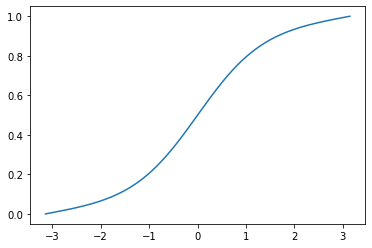

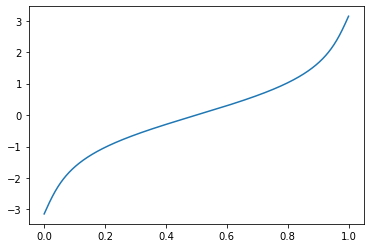

In [416]:
cdf_value = vonmises_line.cdf(-np.pi + 0.1, loc=0, kappa=1)
ppf_value = vonmises_line.ppf(cdf_value, loc=0, kappa=kappa)
cdf_value, ppf_value
# plot cdf function
x = np.linspace(-np.pi, np.pi, 1000)
y = vonmises_line.cdf(x, loc=0, kappa=1)
plt.plot(x, y)
plt.show()

#plot ppf function
x = np.linspace(0, 1, 1000)
y = vonmises_line.ppf(x, loc=0, kappa=1)
plt.plot(x, y)
plt.show()

In [278]:
vonmises_fisher(loc=np.array([0,1]), kappa= 1).rvs(200)

array([[-3.43679746e-01,  9.39086914e-01],
       [ 9.03708256e-01, -4.28148792e-01],
       [ 9.75444254e-01,  2.20246468e-01],
       [-4.97778402e-01,  8.67304250e-01],
       [ 9.99505255e-01,  3.14522655e-02],
       [-9.82843550e-01, -1.84441197e-01],
       [ 8.29900575e-02,  9.96550375e-01],
       [-9.46444351e-01,  3.22866987e-01],
       [ 7.78588542e-01, -6.27534765e-01],
       [ 1.49378526e-01,  9.88780085e-01],
       [ 5.26890204e-01,  8.49933358e-01],
       [ 4.39300733e-01, -8.98340061e-01],
       [-8.69753333e-02,  9.96210465e-01],
       [-2.53991974e-01,  9.67206326e-01],
       [ 1.23823666e-01,  9.92304237e-01],
       [-3.96780312e-01,  9.17913604e-01],
       [ 6.77801843e-01,  7.35244627e-01],
       [-3.30417446e-01,  9.43834896e-01],
       [ 9.87513827e-01, -1.57532352e-01],
       [ 4.91944488e-01,  8.70626568e-01],
       [ 9.83740093e-01,  1.79597964e-01],
       [ 2.84325564e-01,  9.58727789e-01],
       [-5.86470201e-01,  8.09970804e-01],
       [-7.

In [97]:
base = Tree(split_type='2means', mtry=None, impurity_method='cart')
forest = BaggedRegressor(estimator=base, n_estimators=100, bootstrap_fraction=1, bootstrap_replace=True, n_jobs=-1)

In [98]:
theta = hyp_points['t'].values
forest.fit(theta.reshape(-1,1), y)

INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend
INFO: Using numpy backend


BaggedRegressor(bootstrap_fraction=1, bootstrap_replace=True,
                estimator=Tree(split_type='2means'), n_jobs=-1)

In [99]:
preds = forest.predict(theta.reshape(-1,1))

In [101]:
from pyfrechet.metrics import mse
mse(y, preds)

0.008523141656427067